In [5]:
# ============================================================
# CELL 1: INSTALL ALL REQUIRED PACKAGES
# Run this once. Restart kernel after if needed.
# ============================================================

!pip install wfdb pandas numpy matplotlib scikit-learn scipy

In [7]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================buttfatimasajid

import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from collections import Counter

print("All packages loaded successfully ✅")
print(f"  wfdb     : {wfdb.__version__}")
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")

All packages loaded successfully ✅
  wfdb     : 4.3.1
  pandas   : 2.2.3
  numpy    : 2.1.3


In [8]:
# ============================================================
# CELL 3: LOAD METADATA FROM PHYSIONET (100% ONLINE)
# No files saved to disk. Streams directly.
# ============================================================

PHYSIONET_DB  = 'ptb-xl/1.0.3'   # wfdb uses this to locate the remote DB
SAMPLING_RATE = 100               # 100 Hz = 1000 samples per 10s record
                                  # use 500 for high-res (5000 samples)

# ── Metadata CSV ─────────────────────────────────────────────
df = pd.read_csv(
    'https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv',
    index_col='ecg_id'
)
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

# ── SCP diagnostic label definitions ─────────────────────────
scp_df = pd.read_csv(
    'https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv',
    index_col=0
)

print(f"Metadata loaded: {len(df):,} records ✅")

Metadata loaded: 21,799 records ✅


In [9]:
# ============================================================
# CELL 4: FULL DATASET OVERVIEW
# ============================================================

print("=" * 55)
print("  PTB-XL ECG DATASET — OVERVIEW")
print("=" * 55)
print(f"  Total ECG records   : {len(df):,}")
print(f"  Unique patients     : {df['patient_id'].nunique():,}")
print(f"  Age range           : {int(df['age'].min())} – {int(df['age'].max())} years")
print(f"  Sex  (0=M, 1=F)     : {df['sex'].value_counts().to_dict()}")
print(f"  Number of leads     : 12")
print(f"  Record duration     : 10 seconds each")
print(f"  Sampling rates      : 100 Hz and 500 Hz versions available")
print(f"  Recording device    : {df['device'].unique()}")
print()

# ── Fold split ───────────────────────────────────────────────
print("  Stratification folds:")
print("  (Folds 1–8 = Train, 9 = Validation, 10 = Test)\n")
fold_counts = df['strat_fold'].value_counts().sort_index()
for fold, count in fold_counts.items():
    role = "Train" if fold <= 8 else ("Val" if fold == 9 else "Test")
    print(f"    Fold {fold:>2}  [{role:<5}]  : {count:>4} records")

# ── Columns available ────────────────────────────────────────
print(f"\n  All metadata columns ({len(df.columns)}):")
print(f"  {list(df.columns)}")

  PTB-XL ECG DATASET — OVERVIEW
  Total ECG records   : 21,799
  Unique patients     : 18,869
  Age range           : 2 – 300 years
  Sex  (0=M, 1=F)     : {0: 11354, 1: 10445}
  Number of leads     : 12
  Record duration     : 10 seconds each
  Sampling rates      : 100 Hz and 500 Hz versions available
  Recording device    : ['CS-12   E' 'AT-6 C 5.0' 'AT-6 C' 'CS-12' 'AT-6 C 5.5' 'AT-6 C 5.8'
 'AT-6 C 5.6' 'AT-6     6' 'AT-6 C 5.3' 'AT-60    3' 'CS100    3']

  Stratification folds:
  (Folds 1–8 = Train, 9 = Validation, 10 = Test)

    Fold  1  [Train]  : 2175 records
    Fold  2  [Train]  : 2181 records
    Fold  3  [Train]  : 2192 records
    Fold  4  [Train]  : 2174 records
    Fold  5  [Train]  : 2174 records
    Fold  6  [Train]  : 2173 records
    Fold  7  [Train]  : 2176 records
    Fold  8  [Train]  : 2173 records
    Fold  9  [Val  ]  : 2183 records
    Fold 10  [Test ]  : 2198 records

  All metadata columns (27):
  ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 

In [10]:
# ============================================================
# CELL 5: LABEL / DIAGNOSTIC CLASS DISTRIBUTION
# ============================================================

# Filter to diagnostic SCP codes only
diag_scp = scp_df[scp_df.diagnostic == 1]

def get_superclass(scp_codes_dict):
    return [diag_scp.loc[k].diagnostic_class
            for k in scp_codes_dict
            if k in diag_scp.index]

df['superclass'] = df.scp_codes.apply(get_superclass)

# Count
all_labels = [l for labels in df['superclass'] for l in labels]
label_counts = Counter(all_labels)

print("=" * 55)
print("  DIAGNOSTIC CLASS DISTRIBUTION")
print("=" * 55)
print(f"  {'Class':<10} {'Count':>6}   Bar")
print(f"  {'-'*45}")
for label, count in label_counts.most_common():
    bar = '█' * (count // 400)
    print(f"  {label:<10} {count:>6}   {bar}")

print(f"\n  Class meanings:")
print(f"  NORM  = Normal ECG")
print(f"  MI    = Myocardial Infarction")
print(f"  STTC  = ST/T-wave Change")
print(f"  CD    = Conduction Disturbance")
print(f"  HYP   = Hypertrophy")

  DIAGNOSTIC CLASS DISTRIBUTION
  Class       Count   Bar
  ---------------------------------------------
  NORM         9514   ███████████████████████
  MI           6863   █████████████████
  STTC         5771   ██████████████
  CD           5761   ██████████████
  HYP          2812   ███████

  Class meanings:
  NORM  = Normal ECG
  MI    = Myocardial Infarction
  STTC  = ST/T-wave Change
  CD    = Conduction Disturbance
  HYP   = Hypertrophy


In [12]:
# ============================================================
# CELL 6: STREAM ONE ECG RECORD — FIXED PATH
# ============================================================

LEAD_NAMES = ['I','II','III','aVR','aVL','aVF',
              'V1','V2','V3','V4','V5','V6']

# ── Inspect what the path looks like first ───────────────────
print("Raw filename_lr from CSV:", df['filename_lr'].iloc[0])
# Expected: records100/00000/00001_lr

# ── The fix: split folder from record name ───────────────────
raw_path   = df['filename_lr'].iloc[0]          # e.g. records100/00000/00001_lr
folder     = '/'.join(raw_path.split('/')[:-1])  # e.g. records100/00000
rec_name   = raw_path.split('/')[-1]             # e.g. 00001_lr

# wfdb needs: record_name = just the filename
#             pn_dir      = DB root + subfolder
pn_dir_full = f"{PHYSIONET_DB}/{folder}"         # ptb-xl/1.0.3/records100/00000

print(f"pn_dir      : {pn_dir_full}")
print(f"record_name : {rec_name}")

signal, meta = wfdb.rdsamp(rec_name, pn_dir=pn_dir_full)

print("\n" + "=" * 55)
print("  SINGLE RECORD INFO")
print("=" * 55)
print(f"  Signal shape        : {signal.shape}  → (samples, leads)")
print(f"  Sampling frequency  : {meta['fs']} Hz")
print(f"  Lead names          : {meta['sig_name']}")
print(f"  Units               : {meta['units']}")
print(f"  Duration            : {signal.shape[0] / meta['fs']:.1f} seconds")
print(f"  Amplitude range     : {signal.min():.4f}  to  {signal.max():.4f}  mV")

row = df.iloc[0]
print(f"\n  Patient metadata:")
print(f"    Age        : {int(row['age'])} years")
print(f"    Sex        : {'Male' if row['sex'] == 0 else 'Female'}")
print(f"    Diagnosis  : {row['superclass']}")
print(f"    Fold       : {int(row['strat_fold'])}")

Raw filename_lr from CSV: records100/00000/00001_lr
pn_dir      : ptb-xl/1.0.3/records100/00000
record_name : 00001_lr

  SINGLE RECORD INFO
  Signal shape        : (1000, 12)  → (samples, leads)
  Sampling frequency  : 100 Hz
  Lead names          : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
  Units               : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']
  Duration            : 10.0 seconds
  Amplitude range     : -1.3770  to  0.7060  mV

  Patient metadata:
    Age        : 56 years
    Sex        : Female
    Diagnosis  : ['NORM']
    Fold       : 3


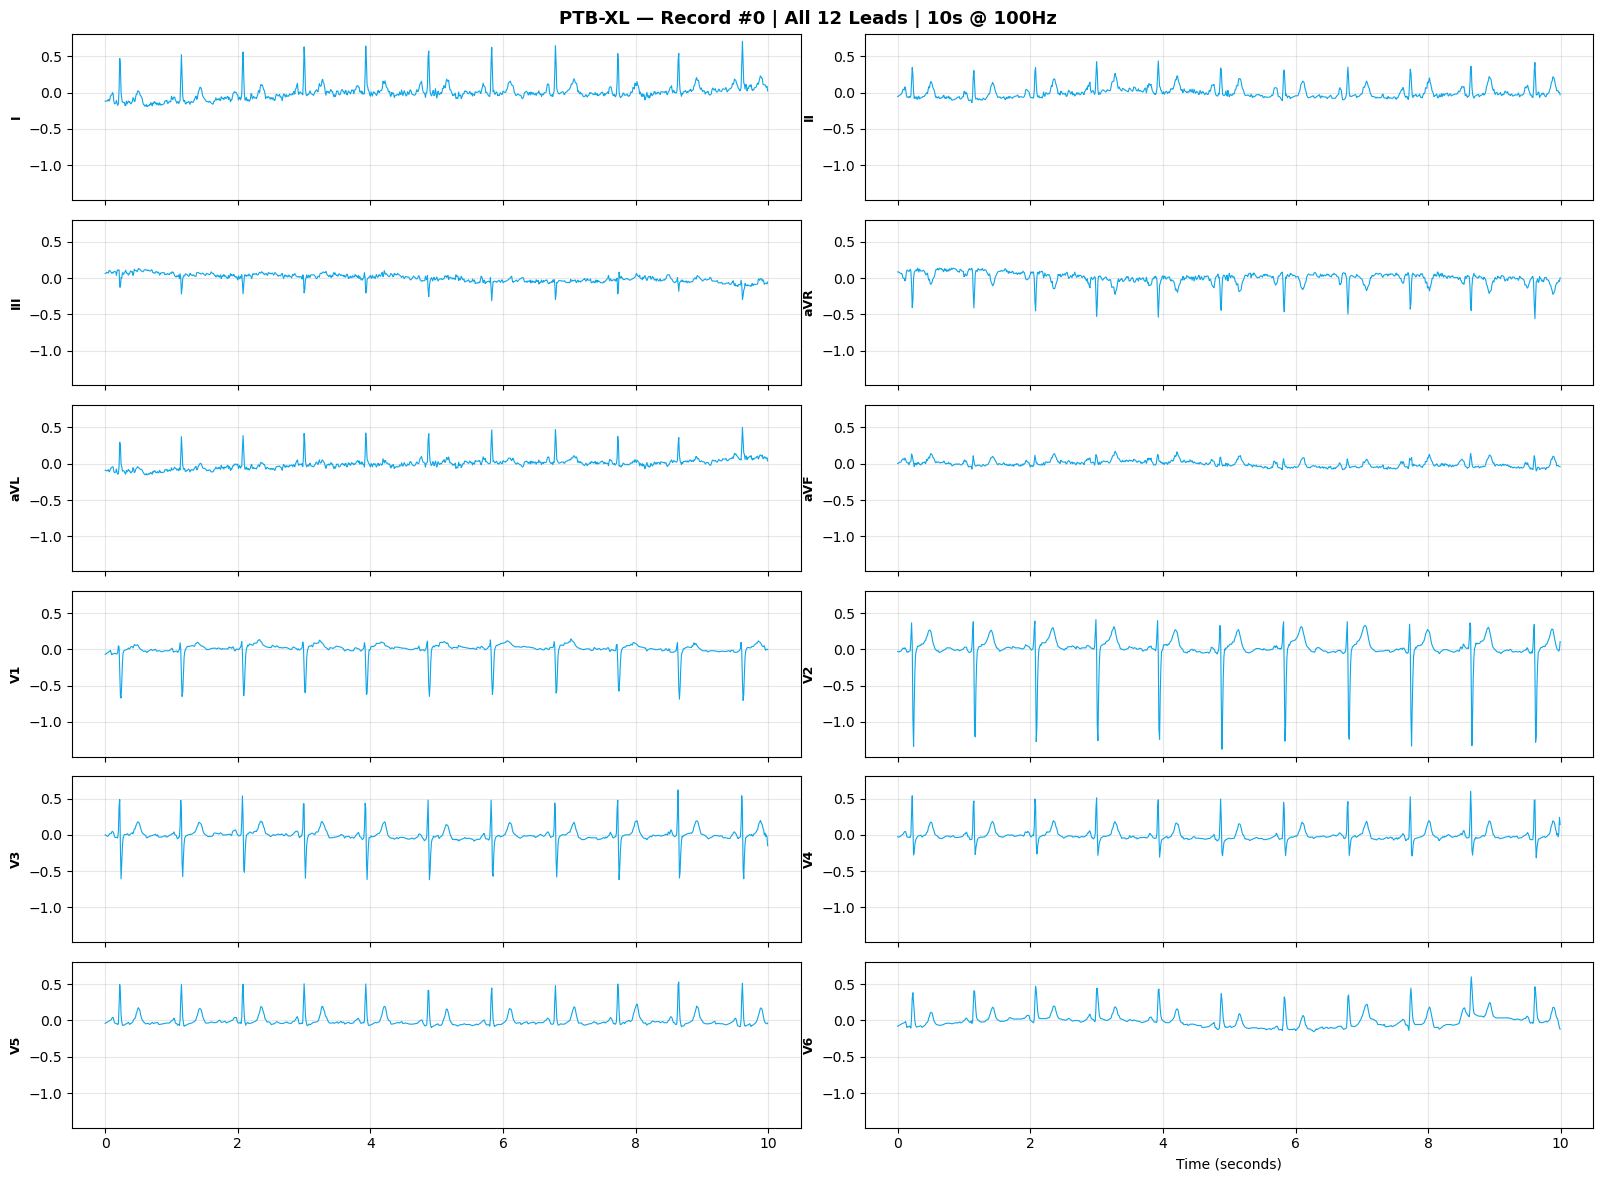

In [13]:
# ============================================================
# CELL 7: PLOT ALL 12 LEADS FOR ONE RECORD
# ============================================================

def plot_12_leads(signal, record_idx=0, fs=100):
    time = np.arange(signal.shape[0]) / fs   # x-axis in seconds

    fig, axes = plt.subplots(6, 2, figsize=(16, 12), sharex=True)
    axes = axes.flatten()

    for i, (ax, name) in enumerate(zip(axes, LEAD_NAMES)):
        ax.plot(time, signal[:, i], color='#0ea5e9', linewidth=0.8)
        ax.set_ylabel(name, fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([signal.min() - 0.1, signal.max() + 0.1])

    axes[-1].set_xlabel('Time (seconds)', fontsize=10)
    fig.suptitle(f'PTB-XL — Record #{record_idx} | All 12 Leads | 10s @ {fs}Hz',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_12_leads(signal, record_idx=0)

In [14]:
# ============================================================
# CELL 8: STREAM BATCH — FIXED PATH VERSION
# ============================================================

def stream_batch(df, n=200, sampling_rate=100):
    col = 'filename_lr' if sampling_rate == 100 else 'filename_hr'
    signals = []

    print(f"Streaming {n} records from PhysioNet at {sampling_rate} Hz...")
    for i, raw_path in enumerate(df[col].iloc[:n]):
        folder   = '/'.join(raw_path.split('/')[:-1])
        rec_name = raw_path.split('/')[-1]
        pn_dir_full = f"{PHYSIONET_DB}/{folder}"

        sig, _ = wfdb.rdsamp(rec_name, pn_dir=pn_dir_full)
        signals.append(sig)

        if (i + 1) % 50 == 0:
            print(f"  → {i+1}/{n} loaded")

    X = np.array(signals)
    print(f"\nDone ✅  Shape: {X.shape}  →  (records, samples, leads)")
    return X

X = stream_batch(df, n=200)

Streaming 200 records from PhysioNet at 100 Hz...
  → 50/200 loaded
  → 100/200 loaded
  → 150/200 loaded
  → 200/200 loaded

Done ✅  Shape: (200, 1000, 12)  →  (records, samples, leads)


In [15]:
# ============================================================
# CELL 9: SIGNAL STATISTICS ACROSS LOADED BATCH
# ============================================================

print("=" * 55)
print("  SIGNAL STATISTICS — BATCH SUMMARY")
print("=" * 55)

for i, name in enumerate(LEAD_NAMES):
    lead_data = X[:, :, i]
    print(f"  {name:<5}  mean={lead_data.mean():+.4f}  "
          f"std={lead_data.std():.4f}  "
          f"min={lead_data.min():+.4f}  "
          f"max={lead_data.max():+.4f}  mV")

print(f"\n  Memory (batch in RAM) : {X.nbytes / 1e6:.1f} MB")

  SIGNAL STATISTICS — BATCH SUMMARY
  I      mean=-0.0010  std=0.1406  min=-1.1540  max=+1.8730  mV
  II     mean=+0.0003  std=0.1893  min=-2.6880  max=+2.6240  mV
  III    mean=+0.0012  std=0.1759  min=-3.5840  max=+1.8150  mV
  aVR    mean=+0.0003  std=0.1417  min=-1.7390  max=+0.9670  mV
  aVL    mean=-0.0010  std=0.1281  min=-1.2280  max=+2.3020  mV
  aVF    mean=+0.0008  std=0.1685  min=-3.0890  max=+2.1970  mV
  V1     mean=+0.0006  std=0.1926  min=-2.7740  max=+1.0820  mV
  V2     mean=-0.0007  std=0.3409  min=-5.6740  max=+2.5810  mV
  V3     mean=-0.0029  std=0.2975  min=-4.7990  max=+4.5960  mV
  V4     mean=-0.0018  std=0.2745  min=-2.9920  max=+4.1240  mV
  V5     mean=+0.0005  std=0.2382  min=-1.3350  max=+3.6610  mV
  V6     mean=+0.0005  std=0.2105  min=-2.2200  max=+2.9820  mV

  Memory (batch in RAM) : 19.2 MB
